# Co-Reading

4단계로 구성.
1. 필요한 리소스 데이터 호출
2. Color mapping 함수
3. KPoEM 감정분류 모델 호출
4. LLM(Gemini 2.5-flash) 호출
5. Co-Reading

## 1. Load Resource Data

- 필요한 라이브러리 및 데이터 로드

In [192]:
import sys

# -----------------------------
# 기본 라이브러리 설치
# -----------------------------
!{sys.executable} -m pip install -U \
    matplotlib \
    python-dotenv \
    google-genai

# -----------------------------
# 기존 충돌 패키지 제거
# (torch / transformers / onnx 계열 초기화)
# -----------------------------
!{sys.executable} -m pip uninstall -y \
    torch torchvision torchaudio \
    transformers optimum \
    onnx onnxruntime

# -----------------------------
# PyTorch 설치
# -----------------------------
!{sys.executable} -m pip install \
    torch torchvision torchaudio

# -----------------------------
# Hugging Face 관련 설치
# -----------------------------
!{sys.executable} -m pip install -U \
    transformers \
    huggingface_hub \
    accelerate \
    safetensors


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Found existing installation: torch 2.12.0
Uninstalling torch-2.12.0:
  Successfully uninstalled torch-2.12.0
Found existing installation: torchvision 0.27.0
Uninstalling torchvision-0.27.0:
  Successfully uninstalled torchvision-0.27.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Found existing installation: transformers 5.11.0
Uninstalling transformers-5.11.0:
  Successfully uninstalled transformers-5.11.0
  Using cached torch-2.12.0-cp310-cp310-macosx_14_0_arm64.whl.metadata (31 kB)
  Using cached torchvision-0.27.0-cp310-cp310-macosx_14_0_arm64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.9 kB)
Using cached torch-2.12.0-cp310-cp310-macosx_14_0_arm64.whl (88.0 MB)
Using cached torchvision-0.27

In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import colorsys
import requests

#### KCoEM 데이터셋 가져오기

In [194]:
# Zenodo record ID (DOI에서 추출)
record_id = "19464212"  # 예: 1234567

url = f"https://zenodo.org/api/records/{record_id}"
response = requests.get(url).json()

# 파일 목록 확인
files = response["files"]

for file in files:
    print(file["key"], file["links"]["self"])

file_url = files[0]["links"]["self"]

df = pd.read_csv(file_url)
print(df.head())

KCoEM2.0.csv https://zenodo.org/api/records/19464212/files/KCoEM2.0.csv/content
   color_id  term_id emotion_term    R    G    B  \
0         1        1           불만  101   49  121   
1         2        2   enthusiasm  185   32   33   
2         3        3           감동  190   26   52   
3         4        3           감동  238  224  253   
4         5        3           감동  169   50  112   

                             emotion_color_reference color_system_source  \
0                  정현희. (2014). 실제 적용 중심의 미술치료. 학지사.        공공디자인색채표준가이드   
1  Nijdam (2005, Table 5), Mapping Emotion to Col...        공공디자인색채표준가이드   
2  김옥. (2017). 감정단어카드를 활용한 유아의 색채반응 연구 [석사학위논문, 광...   R(munsell pakage)   
3  김옥. (2017). 감정단어카드를 활용한 유아의 색채반응 연구 [석사학위논문, 광...   R(munsell pakage)   
4  김옥. (2017). 감정단어카드를 활용한 유아의 색채반응 연구 [석사학위논문, 광...   R(munsell pakage)   

           reference_type  priority color_label color_code  KOTE_id  
0  국내 색채 연상 및 감정 효과 관련 문헌         1          보라          P        0  
1         

In [195]:
# KOTE_id와 감정명 매핑
kote_map = { 
    0: "불평/불만", 1: "환영/호의", 2: "감동/감탄", 3: "지긋지긋",
    4: "고마움", 5: "슬픔", 6: "화남/분노", 7: "존경", 
    8: "기대감", 9: "우쭐댐/무시함", 10: "안타까움/실망",
    11: "비장함", 12: "의심/불신", 13: "뿌듯함",
    14: "편안/쾌적", 15: "신기함/관심", 16: "아껴주는",
    17: "부끄러움", 18: "공포/무서움", 19: "절망",
    20: "한심함", 21: "역겨움/징그러움",
    22: "짜증", 23: "어이없음", 24: "없음",
    25: "패배/자기혐오", 26: "귀찮음", 27: "힘듦/지침",
    28: "즐거움/신남", 29: "깨달음", 30: "죄책감",
    31: "증오/혐오", 32: "흐뭇함(귀여움/예쁨)",
    33: "당황/난처", 34: "경악", 35: "부담/안_내킴",
    36: "서러움", 37: "재미없음", 38: "불쌍함/연민",
    39: "놀람", 40: "행복", 41: "불안/걱정",
    42: "기쁨", 43: "안심/신뢰"
}

In [196]:
# KCoEM 데이터프레임 복사
df_paired = df.copy()

# 1) KOTE_id 전처리 → 리스트화
df_paired["KOTE_id"] = (
    df_paired["KOTE_id"]
    .astype(str)
    .str.replace(r"\s+", "", regex=True)   # 공백 제거
    .str.split(",")                        # 리스트화
)

# 2) explode (행 분해)
df_paired = df_paired.explode("KOTE_id")

# 3) 결측 및 이상값 제거
df_paired = df_paired[
    df_paired["KOTE_id"].notna() &
    (df_paired["KOTE_id"] != "") &
    (df_paired["KOTE_id"] != "nan")
]

# 4) int로 변환
df_paired["KOTE_id"] = df_paired["KOTE_id"].astype(int)

# 5) 감정 이름 매핑
df_paired["KOTE_emotion_name"] = df_paired["KOTE_id"].map(kote_map)

# 확인
print(df_paired[["KOTE_id", "KOTE_emotion_name"]].head())

   KOTE_id KOTE_emotion_name
0        0             불평/불만
1        1             환영/호의
2        2             감동/감탄
3        2             감동/감탄
4        2             감동/감탄


#### I.R.I 데이터 가져오기

- I.R.I 감성형용사 호출

In [197]:
import json
# I.R.I 감성형용사 데이터 호출
with open("../data/grouped_adjectives.json", "r", encoding="utf-8") as f:
    grouped_adjectives = json.load(f)

In [198]:
# 형용사 리스트화
def flatten_adjectives(grouped_dict):
    all_adjectives = []
    
    for adjectives in grouped_dict.values():
        all_adjectives.extend(adjectives)
    
    return all_adjectives

flat_list = flatten_adjectives(grouped_adjectives) #94개의 형용사 리스트

- I.R.I 배색스케일 호출

In [199]:
# CSV 파일 경로
file_path_IRI_colors = "../data/IRI_color_scheme.csv"
# 파일 읽기 (처음엔 컬럼명을 무시하고 불러오기)
df_raw_IRI_colors = pd.read_csv(file_path_IRI_colors, header=None)

# 첫 번째 행을 컬럼명으로 지정
df_raw_IRI_colors.columns = df_raw_IRI_colors.iloc[0]
df_IRI_colors = df_raw_IRI_colors[1:]  # 첫 행은 이제 컬럼으로 사용했으니 제외

In [200]:
#배색스케일에서 흰색 RGB(255, 255, 255), 검정RGB(0,0,0)은 제거
df_IRI_colors = df_IRI_colors[
    # 추가 조건: RGB (0,0,0) 제거
    ~((df_IRI_colors['R'] == '0') & (df_IRI_colors['G'] == '0') & (df_IRI_colors['B'] == '0'))
    &
    # 추가 조건: RGB (255,255,255) 제거
    ~((df_IRI_colors['R'] == '255') & (df_IRI_colors['G'] == '255') & (df_IRI_colors['B'] == '255'))
]
# 결측치 제거
df_IRI_colors = df_IRI_colors.dropna(subset=['R', 'G', 'B'])
df_IRI_colors = df_IRI_colors.dropna(axis=1)

In [201]:
df_IRI_colors[
    df_IRI_colors['형용사군'].str.contains('다이나믹한', na=False)
]

,형용사군,배색그룹id,단일색상 id,R,G,B,Hue,Saturation,Brightness
91,다이나믹한,1,1,206,20,23,358,90,80
93,다이나믹한,1,3,239,125,25,26,89,93
94,다이나믹한,2,1,37,115,59,135,67,45
95,다이나믹한,2,2,196,174,16,52,91,76
96,다이나믹한,2,3,22,66,128,214,82,50
97,다이나믹한,3,1,22,66,136,216,83,53
98,다이나믹한,3,2,206,20,23,358,90,80
101,다이나믹한,4,2,228,35,32,0,85,89
102,다이나믹한,4,3,36,46,93,228,61,36


## 2. color mapping

1-1. 감정 긍/부정, 중립 분류

In [202]:
positive_emotions = ['감동/감탄', '고마움', '기대감', '기쁨', '뿌듯함',
'신기함/관심', '아껴주는', '안심/신뢰', '존경', '즐거움/신남', '편안/쾌적', '행복', '환영/호의',
'흐뭇함(귀여움/예쁨)',
]
negative_emotions = ['경악', '공포/무서움', '귀찮음', '당황/난처', '부끄러움', '부담/안_내킴', '불쌍함/연민', '불안/걱정', 
                     '불평/불만', '슬픔', '서러움', '안타까움/실망', '어이없음', '역겨움/징그러움', '의심/불신', '짜증', 
                     '재미없음', '절망', '죄책감', '증오/혐오', '지긋지긋', '패배/자기혐오', '한심함', '화남/분노', '힘듦/지침', '분노']
neutral_emotions = ['깨달음', '놀람', '비장함', '우쭐댐/무시함']

no_emotion = ['없음']

1-2. 주감정/보조감정에 대해 KCoED데이터셋에서 주색, 보조색을 선정

In [203]:
# 감정 출력 값 전처리 : 없음을 제거, 감정 범주화에 해당하지 않는 감정 제거 ex) 한심함
def filter_emotions(result_emotions):
    # Filter out the '없음' key
    filtered_emotions = {key: value for key, value in result_emotions.items() if key != '없음'}
    
    # Sort the emotions by their values in descending order
    sorted_emotions = sorted(filtered_emotions.items(), key=lambda item: item[1], reverse=True)
    
    # Extract the keys of the top two emotions
    top_two_emotions = [sorted_emotions[0][0], sorted_emotions[1][0]] if len(sorted_emotions) >= 2 else []
    
    return top_two_emotions

In [204]:
# Function to categorize the emotion
def categorize_emotion(primary_emotion, secondary_emotion):
    # 감정 사전 정의 (예시, 필요에 따라 확장 가능)

    # 내부 분류 함수
    def classify(emotion):
        if emotion in positive_emotions:
            return "positive" #긍정
        elif emotion in negative_emotions:
            return "negative" #부정
        elif emotion in neutral_emotions:
            return "neutral" #중립
        else:
            return "no_emotion" #없음
    
    def handle_neutral_case(primary_emotion, secondary_emotion):
        # 감정이 'neutral'인 경우는 별도의 로직으로 처리
        if primary_emotion == "neutral" or secondary_emotion == "neutral":
            return "배색3"

    # 각각 분류
    primary_category = classify(primary_emotion)
    secondary_category = classify(secondary_emotion)
    
    # 'neutral'이 포함된 경우는 별도 함수로 처리 : 배색3
    if "neutral" in [primary_category, secondary_category] :
        print(f"Primary: {primary_category}, Secondary: {secondary_category}")
        return handle_neutral_case(primary_category, secondary_category)
    
    # 조건 비교 후 mode 반환
    if primary_category == secondary_category in ["positive", "negative"]:
        mode1 = "유사색상"
        print(f"Primary: {primary_category}, Secondary: {secondary_category}, Mode : {mode1}")
        return mode1
    else:
        mode1 = "대비색상"
        print(f"Primary: {primary_category}, Secondary: {secondary_category}, Mode : {mode1}")
        return mode1



In [205]:
def get_color(emotion_df, seed=1):
    """
    emotion_df: 이미 특정 감정으로 필터된 DataFrame
    규칙:
      1) 그 안에서 priority 최소값 선택
      2) 동일 priority 복수면 랜덤 1개 선택
    return: 선택된 1개 row(dict) 또는 None
    """

    if emotion_df is None or emotion_df.empty:
        return None

    df = emotion_df.copy()
    
    # priority 숫자로 안전 변환
    df["priority_num"] = pd.to_numeric(df["priority"], errors="coerce")
    df = df.dropna(subset=["priority_num"])

    if df.empty:
        return None

    # priority 최소값만 남김
    min_priority = df["priority_num"].min()
    candidates = df[df["priority_num"] == min_priority]

    if candidates.empty:
        return None

    # 3) 동일 priority 복수면 랜덤 1개
    selected = candidates.sample(n=1).iloc[0]
    # selected = candidates.sample(n=1, random_state=seed).iloc[0] #seed부여해서 고정
    return selected.to_dict()


In [206]:
def get_color_info(top_ranked_value):
    munsell_colors = ['R', 'YR', 'Y', 'GY', 'G', 'BG', 'B', 'PB', 'P', 'RP']
    total = len(munsell_colors)

    if top_ranked_value['color_code'] not in munsell_colors:
        return "unknown_color"
    # 색상약호의 인덱스 찾기
    idx = munsell_colors.index(top_ranked_value['color_code'])

    # 유사색상군
    similar_1_idx = [(idx - 1) % total, (idx + 1) % total]

    # 대비색상군
    contrast_1_idx = [(idx - 4) % total, (idx + 4) % total]
    contrast_idx = [(idx - 5) % total]  # 보색 (정반대 5칸 거리)

    # 변환
    similar_colors_1 = [munsell_colors[i] for i in similar_1_idx]
    contrast_colors_1 = [munsell_colors[i] for i in contrast_1_idx]
    contrast_color = [munsell_colors[i] for i in contrast_idx]

    return {
        "center_color": top_ranked_value,
        "similar_colors_1": similar_colors_1,
        "contrast_colors_1": contrast_colors_1,
        "contrast_color": contrast_color  # 보색
    }
        

In [207]:
def similar_mapping(primary_color_info, secondary_emotion, df):
    # secondary_ranked_value = df[df['감정 어휘'] == secondary_emotion].sort_values(by='평가 순위').iloc[0].to_dict()
    secondary_ranked_df = df[df["KOTE_emotion_name"] == secondary_emotion]
    
    similar_matches = []
    similar_match_exact = []

    # similar_colors 체크
    for similar_color in primary_color_info['similar_colors_1']:
        matched = secondary_ranked_df[secondary_ranked_df['color_code'] == similar_color]
        if not matched.empty:
            similar_matches.append(matched)
            
    # same_color (동일색) 체크
    same_color = primary_color_info['center_color']['color_code']  # 단일 값 리스트 #주색은 미리 딕셔너리로 보관됨. 그대로 가져옴.
    matched_exact = secondary_ranked_df[secondary_ranked_df['color_code'] == same_color]
    if not matched_exact.empty:
        similar_match_exact.append(matched_exact)
    
    # 유사색상군 중 하나라도 일치하는 경우.
    if similar_matches: # 대비색상군1을 우선 선정.
        similar_matches_df = pd.concat(similar_matches).to_dict(orient='records')
        return {"primary_color" : primary_color_info['center_color'],
                    "secondary_color" : min(similar_matches_df, key=lambda x: pd.to_numeric(x['priority'], errors='coerce'))}
            
    # 동일색이 있는경우
    if similar_match_exact:
        similar_dicts = similar_match_exact[0].to_dict(orient='records')
        return {"primary_color" : primary_color_info['center_color'],
                "secondary_color" : min(similar_dicts, key=lambda x: pd.to_numeric(x['priority'], errors='coerce'))} # 'priority'가 가장 높은 값 (숫자가 클수록 높은 순위라면 ↓)
        
    # 유사색상이 없는 경우
    pure_secondary_colors = get_color(secondary_ranked_df, seed=1) # 무작위로 하나 선택 seed부여해서 고정
    return {"primary_color" : primary_color_info['center_color'], "secondary_color" :pure_secondary_colors}

In [208]:
def contrast_mapping(primary_color_info, secondary_emotion, df):
    secondary_ranked_df = df[df["KOTE_emotion_name"] == secondary_emotion]
        
    contrast_matches = []
    contrast_match_exact = []

            
    # contrast_colors_1 체크
    for contrast_color in primary_color_info['contrast_colors_1']:
        matched = secondary_ranked_df[secondary_ranked_df['color_code'] == contrast_color]
        if not matched.empty:
            contrast_matches.append(matched)
            
    # contrast_color (보색) 체크
    contrast_color = primary_color_info['contrast_color'][0]  # 단일 값 리스트
    matched_exact = secondary_ranked_df[secondary_ranked_df['color_code'] == contrast_color]
    if not matched_exact.empty:
        contrast_match_exact.append(matched_exact)
    
    #보색이 정확히 일치하는 경우
    if contrast_match_exact:
        contrast_dicts = contrast_match_exact[0].to_dict(orient='records')
        return {"primary_color" : primary_color_info['center_color'],
                "secondary_color" : min(contrast_dicts, key=lambda x: pd.to_numeric(x['priority'], errors='coerce'))} # '평가 순위'가 가장 높은 값 (숫자가 클수록 높은 순위라면 ↓)
    
    # 대비색상군과 일치하는 경우.
    if contrast_matches: 
        contrast_matches_df = pd.concat(contrast_matches).to_dict(orient='records')
        return {"primary_color" : primary_color_info['center_color'],
                "secondary_color" : min(contrast_matches_df, key=lambda x: pd.to_numeric(x['priority'], errors='coerce'))}
        
    # 대비색상이 없는 경우
    pure_secondary_colors = get_color(secondary_ranked_df, seed=1) # 무작위로 하나 선택 seed부여해서 고정
    return {"primary_color" : primary_color_info['center_color'], "secondary_color" :pure_secondary_colors}  # '평가 순위'가 가장 높은 값 (숫자가 클수록 높은 순위라면 ↓)

In [209]:
def neutral_mapping(primary_color_info, secondary_emotion, df):
    secondary_emotion_df = df[df["KOTE_emotion_name"] == secondary_emotion]
    pure_secondary_color = get_color(secondary_emotion_df, seed=1) # 무작위로 하나 선택 seed부여해서 고정
    return {
        "primary_color": primary_color_info["center_color"],
        "secondary_color": pure_secondary_color
    }

- 감정 긍/부정/중립 범주에 따른 배색 방식 분기

In [210]:
def get_sencondary_color(primary_color_info, secondary_emotion, mode, df):
    # 유사색상 모드일 때
    if mode == "유사색상":
        return similar_mapping(primary_color_info, secondary_emotion, df)
    # 대비색상 모드일 때
    elif mode == "대비색상": 
        return contrast_mapping(primary_color_info, secondary_emotion, df)
    else:
        # 배색3 모드일 때
        return neutral_mapping(primary_color_info, secondary_emotion, df)

    # 예외처리 : 대비색상, 대비색상군1, 대비색상군2가 전부 없는 경우

- rgb 색상값을 hsb로 변환

In [211]:
def rgb_to_hsb(rgb_dict):
    if rgb_dict is None:
        raise ValueError("rgb_to_hsb: rgb_dict is None (secondary_color가 비어있음)")
    # 문자열 RGB 값을 정수로 변환
    # print(rgb_dict)
    r = int(rgb_dict['R']) / 255.0
    g = int(rgb_dict['G']) / 255.0
    b = int(rgb_dict['B']) / 255.0

    # RGB → HSB (HSV)
    h, s, v = colorsys.rgb_to_hsv(r, g, b)

    # HSB 값 반환 (0~360, 0~100, 0~100)
    return {
        'H': round(h * 360), #반올림
        'S': round(s * 100),
        'B': round(v * 100),
        'color info' : rgb_dict
    }

#### 추출한 감정형용사의 형용사군 검색

In [212]:
def find_adjective_group(adjective, grouped_dict):
    """
    주어진 형용사가 속한 형용사군(key)을 반환.
    """
    for group, adjectives in grouped_dict.items():
        if adjective in adjectives:
            return group
    return None  # 못 찾았을 경우

In [213]:
def choose_color_pair(palette_df):
    # 사용할 쌍 정의 (우선순위 순서)
    priority_pairs = [(1, 2), (2, 3), (2, 1), (3, 2)]
    fallback_pairs = [(1, 3), (3, 1)]

    # 현재 데이터프레임에 존재하는 단일색상 id 추출
    available_ids = set(palette_df['단일색상 id'].dropna().astype(int).unique())

    # 가능한 쌍 필터링
    valid_priority_pairs = [pair for pair in priority_pairs if pair[0] in available_ids and pair[1] in available_ids]
    valid_fallback_pairs = [pair for pair in fallback_pairs if pair[0] in available_ids and pair[1] in available_ids]

    # 랜덤 선택
    if valid_priority_pairs:
        return random.choice(valid_priority_pairs)
    elif valid_fallback_pairs:
        return random.choice(valid_fallback_pairs)
    else:
        return None

In [214]:
#
def get_palette_dicts(palette_df):
    """
    palette_result 튜플 (id1, id2)에 대해 해당하는 단일색상id 행을
    각각 dictionary로 반환
    """
    palette_result = choose_color_pair(palette_df)
    id1, id2 = palette_result

    # '단일색상 id' 컬럼이 float일 가능성 있으므로 int로 변환
    df_cast = palette_df.copy()
    df_cast['단일색상 id'] = df_cast['단일색상 id'].astype(int)

    # 각 색상 id에 대응하는 행 추출 후 dict 변환
    primary_row = df_cast[df_cast['단일색상 id'] == id1].iloc[0].to_dict()
    secondary_row = df_cast[df_cast['단일색상 id'] == id2].iloc[0].to_dict()

    return {'primary_palette' : primary_row, 'secondary_palette' : secondary_row}

In [215]:
def update_saturation_brightness(processed_primary_color, processed_secondary_color, palette_result):
    """
    processed_primary_color와 processed_secondary_color의 S, B 값을
    palette_result의 S, B 값으로 업데이트합니다.
    """
    processed_primary_color['S'] = palette_result['primary_palette']['Saturation']
    processed_primary_color['B'] = palette_result['primary_palette']['Brightness']
    processed_secondary_color['S'] = palette_result['secondary_palette']['Saturation']
    processed_secondary_color['B'] = palette_result['secondary_palette']['Brightness']

    return {'updated_primary_color': processed_primary_color,
            'updated_secondary_color': processed_secondary_color
            }

In [216]:
def define_colors(result_emotions, result_IRI, df, IRI_colors_df):
    top_two_emotions = filter_emotions(result_emotions) # 주-보조 감정 결정
    color_mode = categorize_emotion(top_two_emotions[0],top_two_emotions[1]) # 유사색상 vs 대비색상 모드 결정
    filtered_top_emotion = df[df["KOTE_emotion_name"] == top_two_emotions[0]].reset_index(drop=True) # 주 감정으로 데이터프레임 필터링
   
    primary_color = get_color(filtered_top_emotion, seed=1) # 무작위로 하나 선택 seed부여해서 고정
    primary_color_info_data = get_color_info(primary_color) # 주색에 대한 색상 정보 (유사색상군, 대비색상군 등) 추출
    selected_colors = get_sencondary_color(primary_color_info_data, top_two_emotions[1], color_mode, df) # 보조 감정과 모드에 따른 보조색 결정
   
    processed_primary_color = rgb_to_hsb(selected_colors['primary_color']) # 주색 RGB → HSB 변환
    processed_secondary_color = rgb_to_hsb(selected_colors['secondary_color']) # 보조색 RGB → HSB 변환
    
    group_name = find_adjective_group(result_IRI, grouped_adjectives) # 형용사군 찾기
    if group_name:
        print(f"형용사 '{result_IRI}'는 '{group_name}' 형용사군에 속합니다.")
    else:
        print(f"형용사 '{result_IRI}'는 어떤 형용사군에도 속하지 않습니다.")
        
    IRI_colors_df = df_IRI_colors[df_IRI_colors['형용사군'] == group_name]
    # '배색그룹id' 컬럼에서 고유값만 추출
    palette_ids = IRI_colors_df['배색그룹id'].dropna().unique()

    # 랜덤 선택
    if len(palette_ids) > 0:
        chosen_palette_id = random.choice(palette_ids)
        print(f"선택된 배색그룹id: {chosen_palette_id}")
    else:
        chosen_palette_id = None
        print("배색그룹id가 존재하지 않습니다.")
    
    # chosen_palette_id에 해당하는 행만 추출
    palette_df = IRI_colors_df[IRI_colors_df['배색그룹id'] == chosen_palette_id]    
    palette_result = get_palette_dicts(palette_df)
    updated_colors = update_saturation_brightness(processed_primary_color, processed_secondary_color, palette_result)
    updated_colors['primary_emotion'] = top_two_emotions[0]
    updated_colors['secondary_emotion'] = top_two_emotions[1]
    return updated_colors

In [217]:
# HSB → RGB 변환 함수 (matplotlib에서 사용할 수 있는 0-1 범위의 RGB 튜플 반환)
def hsb_to_rgb_tuple(hsb):
    h = int(hsb['H']) / 360
    s = int(hsb['S']) / 100
    v = int(hsb['B']) / 100
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return (r, g, b)  # matplotlib uses 0-1 float RGB

In [218]:
def emotion_to_colors(top_emotions, color_results):
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

    # RGB 변환
    rgb1 = hsb_to_rgb_tuple(color_results['updated_primary_color'])
    rgb2 = hsb_to_rgb_tuple(color_results['updated_secondary_color'])

    # Figure + GridSpec (6:4 비율)
    fig = plt.figure(figsize=(7, 2))
    gs = gridspec.GridSpec(1, 2, width_ratios=[6, 4])

    # Primary Color 영역 (7)
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow([[rgb1]], aspect='auto')
    ax1.set_title("Primary Color", fontsize=10)
    ax1.axis('off')

    # Secondary Color 영역 (3)
    ax2 = fig.add_subplot(gs[1])
    ax2.imshow([[rgb2]], aspect='auto')
    ax2.set_title("Secondary Color", fontsize=10)
    ax2.axis('off')

    # 전체 제목
    # plt.suptitle(f"{top_emotions[2]}, {top_emotions[0]}과(와) {top_emotions[1]}", fontsize=14)
    # 그래프 아래 중앙에 제목 넣기
    fig.text(
        0.5, -0.05,  # x, y (0~1 기준, 아래로 -0.05)
        f"{top_emotions[2]}, {top_emotions[0]}과(와) {top_emotions[1]}",
        ha='center', va='top',
        fontsize=14
)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    
    print(top_emotions, color_results)

## 3. KPoEM 감정분류 모델 로드

In [219]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from huggingface_hub import hf_hub_download
torch.set_float32_matmul_precision('medium')
# 감정분류모델 기초 세팅
REPO_ID = "AKS-DHLAB/KPoEM" # 허깅페이스에 업로드된 감정분류모델 id
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #GPU 사용
THRESH_HOLD = 0.3

In [220]:
class KPoEM_Classifier(nn.Module):
    def __init__(self, repo_id, device):
        super().__init__()

        self.labels = [
            '불평/불만', '환영/호의', '감동/감탄', '지긋지긋', '고마움', '슬픔', '화남/분노', '존경',
            '기대감', '우쭐댐/무시함', '안타까움/실망', '비장함', '의심/불신', '뿌듯함', '편안/쾌적',
            '신기함/관심', '아껴주는', '부끄러움', '공포/무서움', '절망', '한심함', '역겨움/징그러움',
            '짜증', '어이없음', '없음', '패배/자기혐오', '귀찮음', '힘듦/지침', '즐거움/신남', '깨달음',
            '죄책감', '증오/혐오', '흐뭇함(귀여움/예쁨)', '당황/난처', '경악', '부담/안_내킴', '서러움',
            '재미없음', '불쌍함/연민', '놀람', '행복', '불안/걱정', '기쁨', '안심/신뢰'
        ]

        num_labels = len(self.labels)
        self.device = device

        self.tokenizer = AutoTokenizer.from_pretrained(repo_id)
        self.electra = AutoModel.from_pretrained(repo_id)

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.1),
            nn.Linear(self.electra.config.hidden_size, num_labels)
        )

        weights_path = hf_hub_download(
            repo_id=repo_id,
            filename="classifier_state.bin"
        )
        self.classifier.load_state_dict(
            torch.load(weights_path, map_location=self.device)
        )

        self.to(self.device)
        self.eval()

    def forward(self, text: str):
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=512,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
            return_token_type_ids=True,  # 있어도 되고 없어도 됨
        ).to(self.device)

        model_inputs = {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
        }

        # token_type_ids가 실제로 있을 때만 전달
        if "token_type_ids" in encoding:
            model_inputs["token_type_ids"] = encoding["token_type_ids"]

        with torch.no_grad():
            outputs = self.electra(**model_inputs)

        pooled_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled_output)
        return logits

    def analyze(self, text: str, threshold=0.0):
        logits = self.forward(text)
        probabilities = torch.sigmoid(logits.squeeze(0))
        predictions = (probabilities > threshold).int()

        result_dict = {
            self.labels[i]: round(float(probabilities[i].item()), 3)
            for i, pred in enumerate(predictions)
            if pred.item() == 1
        }

        return dict(sorted(result_dict.items(), key=lambda x: x[1], reverse=True))

In [221]:
# KPoEM 모델 로드
print(f"... '{DEVICE}' 환경에서 '{REPO_ID}' 모델을 로드하고 있습니다 ...")
kpoem_model = KPoEM_Classifier(repo_id=REPO_ID, device=DEVICE)
print("KPoEM 모델을 성공적으로 로드하였습니다.")

... 'cpu' 환경에서 'AKS-DHLAB/KPoEM' 모델을 로드하고 있습니다 ...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 20355.18it/s]


KPoEM 모델을 성공적으로 로드하였습니다.


## 3. Gemini 2.5-flash 호출

In [222]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"]) #환경변수로 API 키 관리
MODEL_ID = "gemini-2.5-flash" # 버전 고려. 

In [223]:
def classify_poem_label(poem: str, labels: list[str], verbose: bool = False) -> str:
    # 라벨을 콤마로 연결
    label_list_str = ", ".join(labels)

    prompt = f"""
[역할]
당신은 시를 읽고 단 하나의 형용사 라벨을 부여하는 독자입니다.

[지시 사항]
1. 아래 제공된 '후보 라벨' 목록에서 '시'의 정서와 가장 일치하는 하나를 선택하세요.
2. **반드시** 목록에 있는 라벨만 사용하세요.
3. 결과물에는 선택한 **라벨 외에 어떤 설명이나 문장도 포함하지 마세요.**
4. 라벨의 형태(어미)를 바꾸지 말고 목록에 있는 그대로 출력하세요.

[후보 라벨]
{label_list_str}

[시]
{poem}

[출력 형식]
라벨 하나만 출력하십시오.
""".strip()

    if verbose:
        print(f"--- [PROMPT] ---\n{prompt}\n-----------------")

    # API 호출
    response = client.models.generate_content(
        model=MODEL_ID,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0,      # 일관된 답변을 위해 낮게 설정
            top_p=0.95,
        ),
    )
    print("텍스트", response.text)
    # 응답 처리 (가장 안전한 방식)
    res_text = response.text.strip() if response.text else ""
    
    if verbose:
        print(f"--- [RESPONSE] ---\n{res_text}\n-------------------")

    return res_text

## Co-Reading

In [417]:
# 8️⃣ 전체 체인
def CoReadingPoem(user_input, adjectives):
    # 감정 분석 및 색상 정의
    # reading = classify_poem_label(user_input, adjectives) # 시에 대한 형용사 라벨 추출
    poem_emotions = kpoem_model.analyze(user_input, threshold=THRESH_HOLD) # 시의 감정 분석
    print("감정 분석 결과:", poem_emotions)
    poem_colors = define_colors(poem_emotions, '포근한', df_paired, df_IRI_colors) # 감정에 따른 색상 정의
    emotion_to_colors([poem_colors['primary_emotion'],poem_colors['secondary_emotion'], '포근한'], poem_colors) # 감정과 색상 매핑

감정 분석 결과: {'흐뭇함(귀여움/예쁨)': 0.951, '아껴주는': 0.927, '기쁨': 0.897, '행복': 0.81, '감동/감탄': 0.805, '기대감': 0.799, '신기함/관심': 0.73, '슬픔': 0.6, '환영/호의': 0.568, '즐거움/신남': 0.515, '편안/쾌적': 0.492, '서러움': 0.482, '불쌍함/연민': 0.421, '깨달음': 0.363, '뿌듯함': 0.335}
Primary: positive, Secondary: positive, Mode : 유사색상
형용사 '포근한'는 '내츄럴한' 형용사군에 속합니다.
선택된 배색그룹id: 1


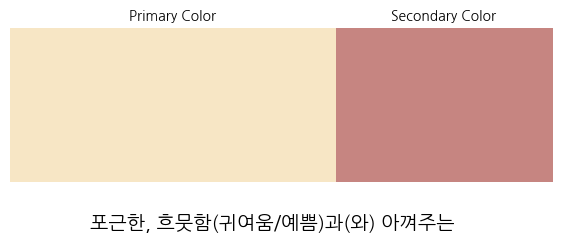

['흐뭇함(귀여움/예쁨)', '아껴주는', '포근한'] {'updated_primary_color': {'H': 39, 'S': '20', 'B': '97', 'color info': {'color_id': 231, 'term_id': 62, 'emotion_term': '만족', 'R': 244, 'G': 157, 'B': 0, 'emotion_color_reference': '김애경, & 오윤경. (2016). 긍정 및 부정 정서어휘에 대한 색 반응 연구. 조형미디어학, 19(1), 59–66.', 'color_system_source': 'HideoSaito. (2013). PCCS (Practical Color Co-ordinate System) color chart [Dataset]. GitHub Gist. https://gist.github.com/hidex7777/5268678', 'reference_type': '한국 성인 대상 감정-색채 연상 실험', 'priority': 1, 'color_label': '주황', 'color_code': 'YR', 'KOTE_id': 32, 'KOTE_emotion_name': '흐뭇함(귀여움/예쁨)', 'priority_num': 1}}, 'updated_secondary_color': {'H': 4, 'S': '35', 'B': '78', 'color info': {'color_id': 128, 'term_id': 37, 'emotion_term': '사랑하다', 'R': 253, 'G': 143, 'B': 136, 'emotion_color_reference': '한지운, & 나건. (2021). 한국 성인의 긍정과 부정 감정 색채 특징. 한국디자인리서치, 6(3), 322-335.', 'color_system_source': nan, 'reference_type': '한국 성인 대상 감정-색채 연상 실험', 'priority': 2, 'color_label': '빨강', 'color_code': 'R'

In [419]:
# 미풍이 웃는 아침을 기원하련다
CoReadingPoem("""눈은 푹푹 나리고
아름다운 나타샤는 나를 사랑하고
어데서 흰 당나귀도 오늘밤이 좋아서 응앙응앙 울을 것이다""", flat_list)

### 색상 검증용 코드 (부록)

In [226]:
import colorsys

def hsb_to_rgb(hsb):

    h = int(hsb['H']) / 360
    s = int(hsb['S']) / 100
    v = int(hsb['B']) / 100

    r, g, b = colorsys.hsv_to_rgb(h, s, v)

    return {
        "r": int(r * 255),
        "g": int(g * 255),
        "b": int(b * 255)
    }
    
primary = hsb_to_rgb ({'H': 173, 'S': 36, 'B': 76})
second = hsb_to_rgb ({'H': 149, 'S': 34, 'B': 98})
print(primary)
print(second)

{'r': 124, 'g': 193, 'b': 185}
{'r': 164, 'g': 249, 'b': 206}


In [227]:
def rgb_to_hsb(rgb_dict):
    if rgb_dict is None:
        raise ValueError("rgb_to_hsb: rgb_dict is None (secondary_color가 비어있음)")
    # 문자열 RGB 값을 정수로 변환
    # print(rgb_dict)
    r = int(rgb_dict['R']) / 255.0
    g = int(rgb_dict['G']) / 255.0
    b = int(rgb_dict['B']) / 255.0

    # RGB → HSB (HSV)
    h, s, v = colorsys.rgb_to_hsv(r, g, b)

    # HSB 값 반환 (0~360, 0~100, 0~100)
    return {
        'H': round(h * 360), #반올림
        'S': round(s * 100),
        'B': round(v * 100),
        'color info' : rgb_dict
    }

In [228]:
print(rgb_to_hsb({'R': 0, 'G': 116, 'B': 56}))

{'H': 149, 'S': 100, 'B': 45, 'color info': {'R': 0, 'G': 116, 'B': 56}}
